# PCA-based Anomaly Detection — Early Warning System Krisis Ekonomi
**Bagian individu:** Sesuai proposal Section **2.1.3.5** (landasan teori) dan **3.2.6** (implementasi)

Notebook ini disusun *step-by-step* supaya kamu paham logikanya, bukan cuma copy-paste. Setiap tahap diberi penjelasan konsep dengan bahasa sederhana dulu, baru kode.

**Alur besar:**
1. Load data
2. Preprocessing (pilih fitur, split, standardisasi)
3. Fit PCA pada data normal → tentukan jumlah komponen (≥95% explained variance)
4. Hitung **SPE (Squared Prediction Error)** → deteksi anomali yang "keluar" dari bidang utama
5. Hitung **Hotelling's T²** → deteksi anomali yang "ekstrem" di dalam bidang utama
6. Tentukan threshold (UCL) dan klasifikasikan anomali
7. Evaluasi terhadap `crisis_label` (AUC-ROC, F1, Precision, Recall)
8. Contribution plot (variabel apa penyebab anomali)

> Catatan: kamu kerja lokal dulu di laptop (Jupyter), baru nanti push ke repo Git kelompok setelah fix — itu alur yang aman, tidak masalah.

## 1. Konsep Dasar (baca dulu sebelum coding)

**Kenapa PCA bisa dipakai deteksi anomali, padahal ini metode reduksi dimensi?**

Bayangkan kamu punya foto 3D suatu objek, lalu kamu memotretnya dari sudut terbaik sehingga jadi foto 2D yang tetap menangkap "bentuk penting"-nya. PCA melakukan hal serupa pada data numerik: ia mencari beberapa arah (disebut **komponen utama / principal component**) yang menangkap sebagian besar variasi (informasi) dari data.

- Data **normal** (kondisi ekonomi biasa) polanya konsisten, sehingga bisa direpresentasikan dengan baik oleh beberapa komponen utama saja.
- Data **anomali** (potensi krisis) punya pola yang menyimpang dari kebiasaan, sehingga sulit direpresentasikan dengan baik oleh komponen-komponen itu.

Karena itu, PCA dilatih **hanya dengan data normal** (`crisis_label = 0`), lalu dipakai untuk mengukur seberapa "aneh" sebuah observasi baru dibanding pola normal itu.

Ada dua ukuran keanehan yang dipakai (sesuai proposal Section 2.1.3.5):

| Statistik | Analoginya | Mendeteksi anomali yang... |
|---|---|---|
| **SPE / Q-statistic** (Squared Prediction Error) | Seberapa jauh titik itu dari "bidang foto" (komponen utama) | Punya pola BARU yang tidak pernah terlihat sebelumnya (jatuh di luar bidang) |
| **Hotelling's T²** | Seberapa jauh titik itu dari pusat, TAPI masih di dalam "bidang foto" | Punya kombinasi nilai yang EKSTREM meski polanya masih "wajar" |

Istilah teknis yang akan sering muncul:
- **Eigenvector**: arah komponen utama (mana arah yang menangkap variasi terbesar).
- **Eigenvalue**: seberapa besar variasi yang ditangkap arah tersebut.
- **Explained variance**: persentase informasi total data yang berhasil ditangkap oleh sejumlah komponen. Kalau 95% explained variance tercapai dengan 5 komponen, artinya 5 komponen itu sudah "cukup mewakili" 16 variabel asli.
- **Reconstruction**: proses mengembalikan data dari ruang komponen utama (yang sudah disederhanakan) kembali ke ruang aslinya. Selisih antara data asli dan hasil reconstruction inilah SPE.
- **UCL (Upper Control Limit)**: ambang batas statistik. Kalau nilai SPE atau T² suatu observasi melebihi UCL, dia dicap anomali.
- **Distribusi chi-square / F**: alat statistik untuk menentukan UCL secara matematis (bukan asal tebak angka), berdasarkan sebaran nilai SPE/T² pada data normal.

## 2. Import Library

Semua library di bawah adalah standar untuk data science di Python — tidak perlu library eksotis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, roc_curve, precision_recall_curve
)
from scipy.stats import chi2, f as f_dist

# Biar plot rapi
plt.rcParams["figure.figsize"] = (8, 4)
np.random.seed(42)  # reproducibility

## 3. Load Data

Sesuai proposal (Section 3.1), dataset bersumber dari **World Bank Global Economic Monitor**, mencakup 49 negara periode 1990–2024, dengan 16 kolom variabel (2 di antaranya `economy` dan `year` adalah identitas, bukan fitur numerik untuk PCA).

Ganti `DATA_PATH` di bawah sesuai lokasi file `data_with_labels.csv` (hasil tahap preprocessing tim kalian di 3.2 — yang sudah punya kolom `crisis_label`). Kalau file itu belum ada dan kamu ingin coba dulu, kamu bisa pakai `data_cleaned.csv` lalu buat `crisis_label` dummy sementara.

In [2]:
DATA_PATH = "data_with_labels.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (1714, 17)


,economy,year,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP,crisis_label
0,ARE,1990,18.327986,11.572665,12.25042,4.890565e+09,1.629,13.129582,89.86458,-0.228435,49.159225,40.705355,33.834707,3.671,7.493889,22.502597,0
1,ARE,1991,0.860082,-4.588785,12.25042,5.646814e+09,1.629,13.129582,89.86458,0.050318,49.159225,40.705355,33.834707,3.671,7.423064,22.502597,0
2,ARE,1992,3.344945,-1.938000,12.25042,5.977161e+09,1.715,13.129582,89.86458,0.239163,49.159225,40.705355,33.834707,3.671,7.583672,22.502597,0
3,ARE,1993,1.261191,-3.631361,12.25042,6.415332e+09,1.901,13.129582,89.86458,0.721472,49.159225,40.705355,33.834707,3.671,7.843781,22.502597,0
4,ARE,1994,6.896149,2.024915,12.25042,6.963510e+09,1.834,13.129582,89.86458,0.105320,49.159225,40.705355,33.834707,3.671,6.587693,22.502597,0


In [3]:
# Cek kolom yang ada, khususnya crisis_label
print(df.columns.tolist())
print("\nDistribusi crisis_label:")
print(df["crisis_label"].value_counts(normalize=True))

['economy', 'year', 'GDP_Growth', 'GDP_PerCapita_Growth', 'Inflation_CPI', 'Total_Reserves', 'Unemployment', 'Current_Account_GDP', 'Trade_GDP', 'FDI_Inflows_GDP', 'Exports_GDP', 'Imports_GDP', 'Gross_Savings_GDP', 'Exchange_Rate', 'Manufacturing_Value', 'Investment_GDP', 'crisis_label']

Distribusi crisis_label:
crisis_label
0    0.808051
1    0.191949
Name: proportion, dtype: float64


## 4. Preprocessing

Langkah ini mengikuti proposal Section 3.2.6 & 3.1.3:

1. **Pilih 14 fitur numerik** (16 kolom dikurangi `economy` dan `year`, yang keduanya adalah identitas/dimensi, bukan indikator ekonomi).
2. **Split data**: 70% train, 15% validasi, 15% test — **tapi data train HANYA berisi observasi normal** (`crisis_label = 0`). Ini penting: PCA harus belajar "seperti apa kondisi normal", jadi tidak boleh "mengintip" data krisis saat training.
3. **Standardisasi (Z-score)**: PCA sensitif terhadap skala. Kalau `Exchange_Rate` bersatuan ribuan sementara `GDP_Growth` bersatuan persen kecil, PCA akan bias ke variabel berskala besar. `StandardScaler` mengubah semua fitur ke rata-rata 0, standar deviasi 1.

   Penting: **scaler di-*fit* hanya pada data train**, lalu dipakai untuk transform val/test. Kalau di-fit ke seluruh data, itu disebut **data leakage** (bocornya informasi masa depan/anomali ke proses training) — bikin hasil evaluasi terlihat bagus padahal menyesatkan.

In [4]:
# 1. Pilih fitur numerik (14 fitur), buang identitas
exclude_cols = ["economy", "year", "crisis_label"]
feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f"Jumlah fitur dipakai: {len(feature_cols)}")
print(feature_cols)

Jumlah fitur dipakai: 14
['GDP_Growth', 'GDP_PerCapita_Growth', 'Inflation_CPI', 'Total_Reserves', 'Unemployment', 'Current_Account_GDP', 'Trade_GDP', 'FDI_Inflows_GDP', 'Exports_GDP', 'Imports_GDP', 'Gross_Savings_GDP', 'Exchange_Rate', 'Manufacturing_Value', 'Investment_GDP']


In [5]:
# 2. Split: train HANYA data normal (crisis_label == 0)
normal_df  = df[df["crisis_label"] == 0].copy()
anomaly_df = df[df["crisis_label"] == 1].copy()

train_df, temp_df = train_test_split(normal_df, test_size=0.30, random_state=42)
val_normal_df, test_normal_df = train_test_split(temp_df, test_size=0.50, random_state=42)

# Data krisis (anomali) dimasukkan ke val & test saja (bukan train) supaya bisa dievaluasi
val_anomaly_df, test_anomaly_df = train_test_split(anomaly_df, test_size=0.50, random_state=42)

val_df  = pd.concat([val_normal_df, val_anomaly_df]).sample(frac=1, random_state=42)
test_df = pd.concat([test_normal_df, test_anomaly_df]).sample(frac=1, random_state=42)

print("Train (normal only):", train_df.shape)
print("Validation (normal+anomali):", val_df.shape)
print("Test (normal+anomali):", test_df.shape)

Train (normal only): (969, 17)
Validation (normal+anomali): (372, 17)
Test (normal+anomali): (373, 17)


In [6]:
# 3. Standardisasi — fit HANYA di train
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_val   = scaler.transform(val_df[feature_cols])
X_test  = scaler.transform(test_df[feature_cols])

y_val  = val_df["crisis_label"].values
y_test = test_df["crisis_label"].values

## 5. Fit PCA & Tentukan Jumlah Komponen

Kita fit PCA dulu dengan semua komponen (`n_components = jumlah fitur`), lalu lihat berapa komponen yang dibutuhkan agar **cumulative explained variance ≥ 95%** (sesuai kriteria di proposal).

Cara membacanya: kalau kamu urutkan komponen dari yang paling "menjelaskan variasi" ke yang paling kecil, lalu jumlahkan persentasenya satu per satu — begitu totalnya menyentuh 95%, itulah jumlah komponen (`k`) yang kita pakai.

Jumlah komponen terpilih (k) untuk >=95% explained variance: 9 dari 14


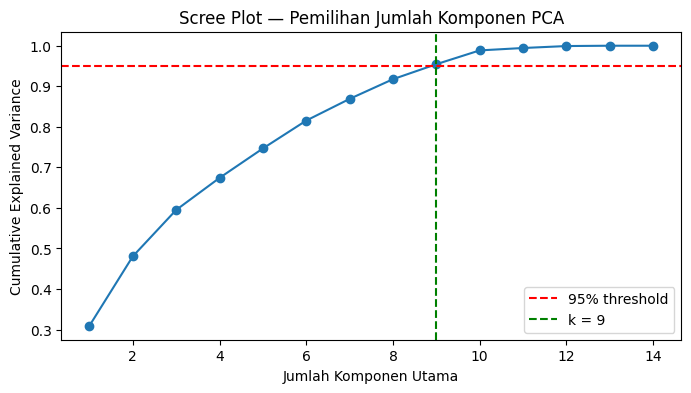

In [7]:
pca_full = PCA(n_components=len(feature_cols), random_state=42)
pca_full.fit(X_train)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
k = np.argmax(cum_var >= 0.95) + 1  # +1 karena index mulai dari 0

print(f"Jumlah komponen terpilih (k) untuk >=95% explained variance: {k} dari {len(feature_cols)}")

plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% threshold")
plt.axvline(k, color="green", linestyle="--", label=f"k = {k}")
plt.xlabel("Jumlah Komponen Utama")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot — Pemilihan Jumlah Komponen PCA")
plt.legend()
plt.show()

In [8]:
# Fit ulang PCA dengan k komponen terpilih ini yang akan dipakai untuk deteksi anomali
pca = PCA(n_components=k, random_state=42)
pca.fit(X_train)

print(f"PCA final dilatih dengan k={k} komponen")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")

PCA final dilatih dengan k=9 komponen
Total explained variance: 0.9544


## 6. Squared Prediction Error (SPE / Q-statistic)

**Cara hitung SPE untuk satu observasi:**
1. Proyeksikan data ke ruang k-komponen: `X_proj = X @ eigenvector`
2. Kembalikan (reconstruct) ke ruang asli: `X_reconstructed = X_proj @ eigenvector.T`
3. SPE = jumlah kuadrat selisih antara data asli dan hasil reconstruction:
   $$SPE = \sum (x_i - \hat{x}_i)^2$$

Semakin besar SPE, semakin "tidak bisa direpresentasikan" observasi itu oleh k komponen utama → indikasi anomali.

**Menentukan UCL (ambang batas) untuk SPE:**
Proposal menyebutkan pendekatan **distribusi chi-square**. Cara umum (metode Jackson & Mudholkar, 1979) adalah menyamakan momen (mean & varians) dari SPE hasil training dengan distribusi chi-square yang diskalakan, lalu ambil persentil ke-95 sebagai UCL. Simpelnya: kita pelajari "seberapa besar SPE itu wajar" dari data training (yang seluruhnya normal), baru pakai itu sebagai patokan.

In [9]:
def compute_spe(X, pca_model):
    """Hitung SPE (reconstruction error) untuk setiap baris di X."""
    X_proj = pca_model.transform(X)                  # proyeksi ke ruang PC
    X_reconstructed = pca_model.inverse_transform(X_proj)  # kembalikan ke ruang asli
    spe = np.sum((X - X_reconstructed) ** 2, axis=1)
    return spe

def spe_ucl(spe_train, alpha=0.05):
    """Hitung UCL SPE via pendekatan chi-square (Jackson & Mudholkar, 1979)."""
    mean_spe = np.mean(spe_train)
    var_spe  = np.var(spe_train)
    g = var_spe / (2 * mean_spe)          # faktor skala
    h = (2 * mean_spe ** 2) / var_spe     # derajat bebas efektif
    ucl = g * chi2.ppf(1 - alpha, h)
    return ucl

# Hitung SPE di training untuk menentukan UCL
spe_train = compute_spe(X_train, pca)
ucl_spe = spe_ucl(spe_train, alpha=0.05)

print(f"UCL SPE (95%): {ucl_spe:.4f}")

UCL SPE (95%): 2.4258


## 7. Hotelling's T² Statistic

Kalau SPE mengukur jarak *di luar* bidang komponen utama, T² mengukur jarak *di dalam* bidang itu — apakah kombinasi nilai suatu observasi (dalam ruang komponen utama yang sudah direduksi) terlalu ekstrem dibanding pusat data normal.

**Rumus T²** untuk satu observasi (dalam ruang k-komponen):
$$T^2 = \sum_{i=1}^{k} \frac{t_i^2}{\lambda_i}$$
di mana $t_i$ adalah skor komponen ke-i, dan $\lambda_i$ adalah eigenvalue (variansi) komponen ke-i. Pembagian dengan eigenvalue ini semacam "normalisasi" — komponen dengan variansi kecil dibobot lebih besar terhadap penyimpangan kecil pada komponen tersebut.

**UCL untuk T²** memakai distribusi F (standar dalam literatur Hotelling's T²):
$$UCL_{T^2} = \frac{k(n-1)}{n-k} F_{\alpha}(k,\ n-k)$$
dengan $n$ = jumlah observasi training, $k$ = jumlah komponen.

In [10]:
def compute_t2(X, pca_model):
    """Hitung Hotelling's T^2 untuk setiap baris di X."""
    X_proj = pca_model.transform(X)                 # skor komponen (t_i)
    eigenvalues = pca_model.explained_variance_      # lambda_i
    t2 = np.sum((X_proj ** 2) / eigenvalues, axis=1)
    return t2

def t2_ucl(n_train, k, alpha=0.05):
    """Hitung UCL T^2 via distribusi F."""
    f_crit = f_dist.ppf(1 - alpha, k, n_train - k)
    ucl = (k * (n_train - 1) / (n_train - k)) * f_crit
    return ucl

n_train = X_train.shape[0]
ucl_t2 = t2_ucl(n_train, k, alpha=0.05)

print(f"UCL T^2 (95%): {ucl_t2:.4f}")

UCL T^2 (95%): 17.1483


## 8. Klasifikasi Anomali

Sesuai proposal: **observasi dianggap anomali jika SPE melebihi UCL-nya ATAU T² melebihi UCL-nya** (kombinasi keduanya, karena masing-masing menangkap jenis penyimpangan yang berbeda).

In [11]:
def detect_anomaly(X, pca_model, ucl_spe, ucl_t2):
    spe = compute_spe(X, pca_model)
    t2  = compute_t2(X, pca_model)
    is_anomaly = (spe > ucl_spe) | (t2 > ucl_t2)
    return pd.DataFrame({"SPE": spe, "T2": t2, "is_anomaly": is_anomaly.astype(int)})

val_result  = detect_anomaly(X_val, pca, ucl_spe, ucl_t2)
test_result = detect_anomaly(X_test, pca, ucl_spe, ucl_t2)

val_result["crisis_label"] = y_val
test_result["crisis_label"] = y_test

test_result.head()

,SPE,T2,is_anomaly,crisis_label
0,0.043390,6.881223,0,1
1,1.795084,3.592686,0,0
2,2.693418,20.166105,1,0
3,1.494872,7.779226,0,1
4,0.411892,7.780257,0,0


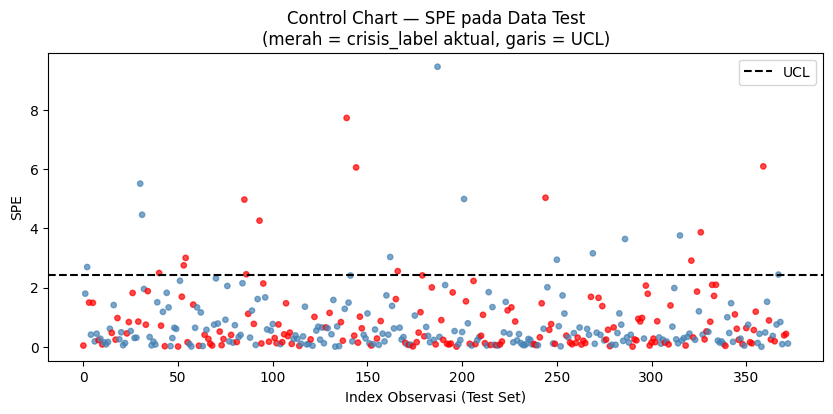

In [12]:
# Control chart sederhana untuk SPE pada data test
plt.figure(figsize=(10, 4))
colors = np.where(test_result["crisis_label"] == 1, "red", "steelblue")
plt.scatter(range(len(test_result)), test_result["SPE"], c=colors, s=15, alpha=0.7)
plt.axhline(ucl_spe, color="black", linestyle="--", label="UCL")
plt.xlabel("Index Observasi (Test Set)")
plt.ylabel("SPE")
plt.title("Control Chart — SPE pada Data Test\n(merah = crisis_label aktual, garis = UCL)")
plt.legend()
plt.show()

## 9. Evaluasi terhadap `crisis_label`

Sesuai proposal Section 3.4: gunakan **AUC-ROC** (metrik utama, cocok untuk kelas tidak seimbang) serta **F1-Score, Precision, Recall, Average Precision** (metrik sekunder untuk kelas minoritas/anomali).

Untuk AUC-ROC, kita butuh skor kontinu (bukan label biner) — kita bisa pakai SPE atau T², atau gabungan keduanya (mis. dinormalisasi lalu dijumlah) sebagai *anomaly score*.

In [13]:
# Anomaly score kontinu: gabungan SPE dan T2 yang dinormalisasi terhadap UCL masing-masing
def anomaly_score(result_df, ucl_spe, ucl_t2):
    return (result_df["SPE"] / ucl_spe) + (result_df["T2"] / ucl_t2)

test_result["anomaly_score"] = anomaly_score(test_result, ucl_spe, ucl_t2)

y_true  = test_result["crisis_label"]
y_score = test_result["anomaly_score"]
y_pred  = test_result["is_anomaly"]

print(f"AUC-ROC            : {roc_auc_score(y_true, y_score):.4f}")
print(f"F1-Score            : {f1_score(y_true, y_pred):.4f}")
print(f"Precision           : {precision_score(y_true, y_pred):.4f}")
print(f"Recall              : {recall_score(y_true, y_pred):.4f}")
print(f"Average Precision   : {average_precision_score(y_true, y_score):.4f}")

AUC-ROC            : 0.6414
F1-Score            : 0.3984
Precision           : 0.6049
Recall              : 0.2970
Average Precision   : 0.5785


## 10. Contribution Plot (Interpretabilitas)

Proposal Section 3.2.6 menyebutkan **contribution plot** untuk mengetahui variabel apa yang paling menyebabkan sebuah observasi terdeteksi anomali — ini nilai tambah PCA dibanding metode "black box" seperti Autoencoder.

Idenya: untuk SPE, kontribusi tiap variabel adalah seberapa besar selisih (residual) antara nilai asli dan hasil rekonstruksi pada variabel itu. Variabel dengan residual terbesar = penyumbang utama anomali.

Top 5 variabel penyumbang anomali pada observasi ini:
GDP_Growth              2.010000
GDP_PerCapita_Growth    1.637192
Gross_Savings_GDP       1.606996
Total_Reserves          0.442374
Current_Account_GDP     0.151497
dtype: float64


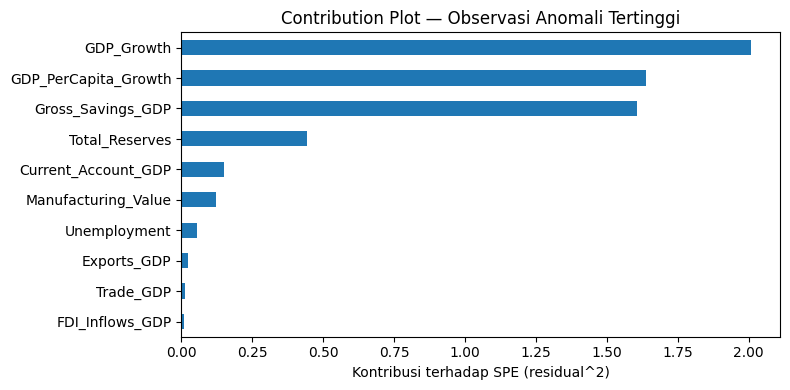

In [14]:
def spe_contribution(x_row, pca_model, feature_names):
    """Kontribusi tiap variabel terhadap SPE untuk SATU observasi (1D array)."""
    x_row = x_row.reshape(1, -1)
    x_proj = pca_model.transform(x_row)
    x_reconstructed = pca_model.inverse_transform(x_proj)
    residual_sq = (x_row - x_reconstructed) ** 2
    contrib = pd.Series(residual_sq.flatten(), index=feature_names).sort_values(ascending=False)
    return contrib

# Contoh: ambil observasi test dengan anomaly_score tertinggi (paling "aneh")
idx_top_anomaly = test_result["anomaly_score"].idxmax()
row_position = test_result.index.get_loc(idx_top_anomaly)
x_example = X_test[row_position]

contrib = spe_contribution(x_example, pca, feature_cols)
print("Top 5 variabel penyumbang anomali pada observasi ini:")
print(contrib.head(5))

contrib.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Kontribusi terhadap SPE (residual^2)")
plt.title("Contribution Plot — Observasi Anomali Tertinggi")
plt.tight_layout()
plt.show()

## 11. Ringkasan & Langkah Selanjutnya

Yang sudah dilakukan sesuai proposal:
- ✅ PCA dilatih hanya pada data normal, k ditentukan dari 95% cumulative explained variance
- ✅ SPE dihitung + UCL via pendekatan chi-square
- ✅ Hotelling's T² dihitung + UCL via distribusi F
- ✅ Klasifikasi anomali: SPE > UCL **atau** T² > UCL
- ✅ Evaluasi: AUC-ROC, F1, Precision, Recall, Average Precision
- ✅ Contribution plot untuk interpretasi

**Yang perlu kamu sesuaikan:**
- Path file data (`DATA_PATH`) — samakan dengan hasil preprocessing tim kalian (Tahap 2 di alur penelitian, section 3.3).
- Kalau tim sudah sepakat pakai split train/val/test yang sama untuk semua algoritma (Isolation Forest, LOF, Autoencoder, OCSVM, DBSCAN), pastikan kamu pakai **random_state yang sama** dan porsi yang identik supaya perbandingan antar-model adil (apple-to-apple).
- Simpan hasil (`test_result`, metrik evaluasi) ke CSV terpisah supaya mudah digabung teman satu kelompok untuk Tahap 6 (Evaluasi dan Seleksi Model) dan Tahap 7 (Validasi Eksternal).

**Soal tooling — Google AI Studio vs Google Colab:**
- **Google AI Studio** itu untuk *prompting* model Gemini (chat/API playground) — bukan tempat menjalankan notebook Python untuk data science.
- **Google Colab** (colab.research.google.com) itu yang kamu maksud — notebook Jupyter gratis di cloud, sudah ada `numpy`, `pandas`, `scikit-learn`, `scipy`, `matplotlib` (semua library di notebook ini) tanpa instalasi. Cocok kalau laptop kamu terbatas resource, atau mau kolaborasi (bisa share link, walau tidak seideal Git untuk version control tim kalian).
- Karena kamu sudah kerja di Jupyter Notebook lokal, itu juga valid — tidak wajib pindah ke Colab. Kalau butuh compute lebih besar atau mau akses dari device lain, baru Colab jadi opsi. Alur kamu (kerja lokal dulu → push ke Git kelompok setelah fix) sudah tepat, tidak perlu diubah.

## 12. Interpretasi Hasil & Perbandingan dengan Data Normal

Ini bagian PALING PENTING untuk laporan (Bab 4 Hasil dan Pembahasan) — angka metrik saja (AUC-ROC, F1, dll) belum cukup, dosen/penguji pasti tanya "artinya apa?". Bagian ini menjawab: **variabel apa yang membuat suatu observasi dianggap anomali, dan apakah pola itu masuk akal secara ekonomi?**

> Semua kode di bawah menghitung langsung dari hasil deteksimu (`test_result`, `X_test`) — jadi begitu kamu jalankan dengan data asli, angka & narasinya otomatis mengikuti datamu sendiri, bukan hasil karangan.

In [15]:
# Gabungkan kembali fitur ASLI (belum distandardisasi) dari test_df dengan hasil deteksi,
# supaya angkanya mudah dibaca (mis. Exchange_Rate dalam satuan aslinya, bukan Z-score)
test_df_reset = test_df.reset_index(drop=True)
combined = pd.concat(
    [test_df_reset[["economy", "year"] + feature_cols].reset_index(drop=True),
     test_result.reset_index(drop=True)],
    axis=1
)

# Versi X_test yang SUDAH distandardisasi, dipakai untuk hitung effect size yang adil antar variabel
X_test_scaled_df = pd.DataFrame(X_test, columns=feature_cols)
combined_scaled = pd.concat([X_test_scaled_df, test_result.reset_index(drop=True)], axis=1)

combined.head()

,economy,year,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,...,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP,SPE,T2,is_anomaly,crisis_label,anomaly_score
0,PRT,2011,-1.713527,-1.568857,3.653011,2.080130e+10,12.715,-6.118548,73.007576,4.236488,...,38.596063,13.252701,0.718414,11.328789,18.661380,0.043390,6.881223,0,1,0.419165
1,KEN,2005,5.906666,2.702441,10.312778,1.799088e+09,2.739,-1.346558,64.478866,0.113202,...,35.969836,13.872696,75.554109,10.536086,17.649685,1.795084,3.592686,0,0,0.949510
2,SAU,2007,2.213654,-1.940861,4.167824,3.092873e+11,5.734,24.548304,94.863317,1.484579,...,34.925877,48.927719,3.750000,9.768307,26.472918,2.693418,20.166105,1,0,2.286316
3,RUS,1996,-3.755069,-3.614975,47.752012,1.625762e+10,9.665,2.578983,47.922501,0.658454,...,21.849513,27.115923,5.120833,15.193445,23.667400,1.494872,7.779226,0,1,1.069889
4,ESP,2017,2.896042,2.646171,1.956076,6.940020e+10,17.224,2.828577,66.167446,2.540392,...,31.267051,22.364257,0.885206,11.114558,19.565667,0.411892,7.780257,0,0,0.623503


### 12.1 Rata-rata Tiap Variabel: Kelompok Anomali vs Kelompok Normal

Tabel ini membandingkan rata-rata tiap indikator makroekonomi antara observasi yang ditandai anomali (`is_anomaly=1`) vs yang dianggap normal (`is_anomaly=0`). Variabel dengan selisih paling besar = paling "mencolok" bedanya.

In [16]:
desc_by_pred = combined.groupby("is_anomaly")[feature_cols].mean().T
desc_by_pred.columns = ["Rata-rata (Normal)", "Rata-rata (Anomali)"]
desc_by_pred["Selisih (Anomali - Normal)"] = (
    desc_by_pred["Rata-rata (Anomali)"] - desc_by_pred["Rata-rata (Normal)"]
)
desc_by_pred.sort_values("Selisih (Anomali - Normal)", key=abs, ascending=False)

,Rata-rata (Normal),Rata-rata (Anomali),Selisih (Anomali - Normal)
Total_Reserves,9.464938e+10,2.662964e+11,1.716470e+11
Exchange_Rate,3.117002e+02,1.625215e+03,1.313514e+03
Inflation_CPI,7.254593e+00,8.717583e+01,7.992124e+01
Trade_GDP,6.779186e+01,1.011951e+02,3.340319e+01
Exports_GDP,3.410702e+01,5.286770e+01,1.876068e+01
Imports_GDP,3.368484e+01,4.832735e+01,1.464251e+01
Gross_Savings_GDP,2.300594e+01,2.825731e+01,5.251377e+00
Manufacturing_Value,1.612584e+01,1.867982e+01,2.553979e+00
Investment_GDP,2.337770e+01,2.591648e+01,2.538788e+00
GDP_PerCapita_Growth,1.763488e+00,-3.764589e-01,-2.139947e+00


### 12.2 Effect Size — Variabel Mana yang Paling "Membedakan" Anomali?

Selisih rata-rata mentah (12.1) sulit dibandingkan antar variabel karena satuannya beda-beda (persen vs rupiah, dst). Di sini kita hitung **effect size** (selisih rata-rata yang sudah dinormalisasi terhadap sebaran datanya, mirip konsep Cohen's d) memakai data yang sudah distandardisasi — jadi semua variabel bisa dibandingkan apel-ke-apel.

Effect size positif besar = variabel itu jauh LEBIH TINGGI di kelompok anomali. Effect size negatif besar = jauh LEBIH RENDAH di kelompok anomali.

Effect size tiap variabel (diurutkan dari paling membedakan):
Gross_Savings_GDP       0.582309
Exports_GDP             0.507605
Trade_GDP               0.488501
Imports_GDP             0.460579
GDP_PerCapita_Growth   -0.444912
Manufacturing_Value     0.421137
GDP_Growth             -0.377325
Exchange_Rate           0.346939
Investment_GDP          0.335821
Total_Reserves          0.321183
Current_Account_GDP     0.296553
Inflation_CPI           0.283300
Unemployment            0.223509
FDI_Inflows_GDP         0.057137
dtype: float64


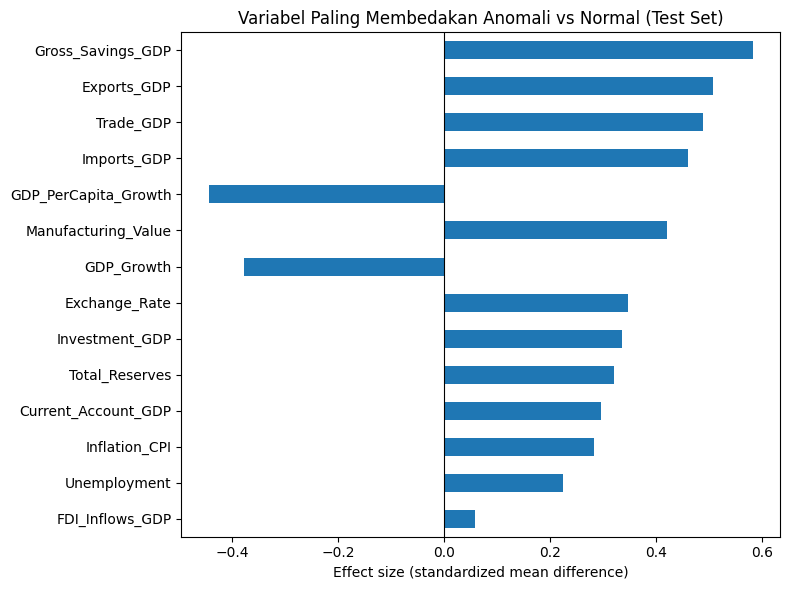

In [17]:
def effect_size(df_scaled, feature, group_col="is_anomaly"):
    g1 = df_scaled.loc[df_scaled[group_col] == 1, feature]
    g0 = df_scaled.loc[df_scaled[group_col] == 0, feature]
    pooled_std = np.sqrt((g1.var() + g0.var()) / 2)
    if pooled_std == 0 or np.isnan(pooled_std):
        return 0.0
    return (g1.mean() - g0.mean()) / pooled_std

effect_sizes = pd.Series(
    {f: effect_size(combined_scaled, f) for f in feature_cols}
).sort_values(key=abs, ascending=False)

print("Effect size tiap variabel (diurutkan dari paling membedakan):")
print(effect_sizes)

effect_sizes.plot(kind="barh", figsize=(8, 6))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Effect size (standardized mean difference)")
plt.title("Variabel Paling Membedakan Anomali vs Normal (Test Set)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 12.3 Draf Narasi Interpretasi (Otomatis dari Hasilmu)

Kode di bawah menyusun draf kalimat berdasarkan effect size di atas. **Ini titik awal, bukan hasil final** — baca dulu, cek apakah masuk akal secara ekonomi, baru dihaluskan bahasanya untuk laporan.

In [18]:
top_n = 5
top_features = effect_sizes.abs().sort_values(ascending=False).head(top_n).index

print("=== Draf narasi interpretasi (edit bahasa sesuai gaya laporanmu) ===\n")
for feat in top_features:
    es = effect_sizes[feat]
    arah = "lebih TINGGI" if es > 0 else "lebih RENDAH"
    print(f"- Observasi yang terdeteksi anomali menunjukkan nilai {feat} yang {arah} "
          f"secara signifikan dibanding observasi normal (effect size = {es:.2f}).")

print("\nKesimpulan awal: kombinasi variabel-variabel di atas adalah 'signature' utama")
print("yang membuat PCA menandai suatu observasi sebagai anomali. Bandingkan pola ini")
print("dengan literatur krisis (mis. tekanan nilai tukar & inflasi tinggi = signature krisis mata uang).")

=== Draf narasi interpretasi (edit bahasa sesuai gaya laporanmu) ===

- Observasi yang terdeteksi anomali menunjukkan nilai Gross_Savings_GDP yang lebih TINGGI secara signifikan dibanding observasi normal (effect size = 0.58).
- Observasi yang terdeteksi anomali menunjukkan nilai Exports_GDP yang lebih TINGGI secara signifikan dibanding observasi normal (effect size = 0.51).
- Observasi yang terdeteksi anomali menunjukkan nilai Trade_GDP yang lebih TINGGI secara signifikan dibanding observasi normal (effect size = 0.49).
- Observasi yang terdeteksi anomali menunjukkan nilai Imports_GDP yang lebih TINGGI secara signifikan dibanding observasi normal (effect size = 0.46).
- Observasi yang terdeteksi anomali menunjukkan nilai GDP_PerCapita_Growth yang lebih RENDAH secara signifikan dibanding observasi normal (effect size = -0.44).

Kesimpulan awal: kombinasi variabel-variabel di atas adalah 'signature' utama
yang membuat PCA menandai suatu observasi sebagai anomali. Bandingkan pola ini
den

### 12.4 Cocokkan dengan `crisis_label` Aktual (Validasi)

Bagian ini memecah hasil deteksi jadi 4 kemungkinan (confusion matrix), supaya kamu bisa cerita bukan cuma "akurasinya sekian persen" tapi juga risiko praktisnya — terutama **False Negative** (krisis yang lolos dari deteksi), karena ini yang paling berbahaya untuk sistem EWS.

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_result["crisis_label"], test_result["is_anomaly"])
tn, fp, fn, tp = cm.ravel()

print(f"True Positive  (anomali & memang krisis)      : {tp}")
print(f"False Positive (anomali tapi TIDAK krisis)     : {fp}  <- 'false alarm'")
print(f"False Negative (TIDAK anomali tapi krisis)     : {fn}  <- krisis lolos deteksi, paling berisiko")
print(f"True Negative  (tidak anomali & memang normal) : {tn}")

if (tp + fn) > 0:
    print(f"\nDari {tp+fn} observasi krisis aktual di test set, "
          f"model berhasil mendeteksi {tp} ({tp/(tp+fn)*100:.1f}%).")
if (tp + fp) > 0:
    print(f"Dari {tp+fp} observasi yang ditandai anomali, "
          f"{tp} ({tp/(tp+fp)*100:.1f}%) memang benar krisis (ini precision).")

True Positive  (anomali & memang krisis)      : 49
False Positive (anomali tapi TIDAK krisis)     : 32  <- 'false alarm'
False Negative (TIDAK anomali tapi krisis)     : 116  <- krisis lolos deteksi, paling berisiko
True Negative  (tidak anomali & memang normal) : 176

Dari 165 observasi krisis aktual di test set, model berhasil mendeteksi 49 (29.7%).
Dari 81 observasi yang ditandai anomali, 49 (60.5%) memang benar krisis (ini precision).


### 12.5 Cek Konsistensi — Contribution Plot untuk Beberapa Kasus True Positive

Section 10 sudah menunjukkan contribution plot untuk SATU observasi anomali tertinggi. Di sini kita cek beberapa kasus **True Positive** (anomali yang memang krisis) sekaligus — kalau variabel penyumbangnya konsisten mirip, itu memperkuat argumen bahwa PCA menangkap pola krisis yang nyata, bukan kebetulan.

In [20]:
tp_mask = (test_result["is_anomaly"] == 1) & (test_result["crisis_label"] == 1)
tp_indices = test_result[tp_mask].sort_values("anomaly_score", ascending=False).head(3).index

for idx in tp_indices:
    row_pos = test_result.index.get_loc(idx)
    row_info = test_df_reset.iloc[row_pos]
    contrib_i = spe_contribution(X_test[row_pos], pca, feature_cols)
    print(f"--- {row_info['economy']} tahun {int(row_info['year'])} "
          f"(anomaly_score={test_result.loc[idx, 'anomaly_score']:.2f}) ---")
    print(contrib_i.head(3))
    print()

--- BRA tahun 1990 (anomaly_score=371.87) ---
GDP_Growth              2.010000
GDP_PerCapita_Growth    1.637192
Gross_Savings_GDP       1.606996
dtype: float64

--- BRA tahun 1993 (anomaly_score=157.38) ---
GDP_PerCapita_Growth    0.74141
GDP_Growth              0.70663
Gross_Savings_GDP       0.25938
dtype: float64

--- RUS tahun 1991 (anomaly_score=36.12) ---
Investment_GDP    2.438945
Total_Reserves    2.353955
GDP_Growth        0.697625
dtype: float64



### 12.6 Checklist Bab Pembahasan untuk Laporan

Pakai urutan ini supaya pembahasanmu runtut dan lengkap:

1. **Angka metrik** (dari Section 9): AUC-ROC, F1, Precision, Recall — laporkan apa adanya, bandingkan sekilas dengan 5 algoritma lain punya kelompok.
2. **Variabel pembeda utama** (12.1–12.3): jelaskan variabel mana yang jadi "signature" anomali, dan apakah itu masuk akal secara teori ekonomi (mis. lonjakan Exchange_Rate & Inflation = krisis mata uang; penurunan tajam GDP_Growth & Total_Reserves = krisis eksternal).
3. **Trade-off False Positive vs False Negative** (12.4): jelaskan risiko praktis — EWS yang banyak false alarm bikin orang tidak percaya, tapi EWS yang banyak lolos (false negative) berbahaya karena krisis tidak terdeteksi.
4. **Konsistensi lintas kasus** (12.5): apakah beberapa periode krisis berbeda (misal krisis di negara/tahun berbeda) punya "signature" variabel yang mirip atau beda-beda? Ini menunjukkan apakah krisis punya pola umum atau sangat spesifik per kasus.
5. **Konteks historis**: cek nama negara & tahun yang terdeteksi (`economy`, `year` di section 12.5) — apakah cocok dengan krisis yang kamu tahu (Krisis Asia 1997–98, Krisis Global 2008–09, COVID 2020)? Ini memperkuat validitas hasil di mata pembaca laporan.
6. **Keterbatasan**: PCA mengasumsikan hubungan **linier** antar variabel — kalau ada pola anomali yang sifatnya non-linier, PCA mungkin kurang sensitif dibanding Autoencoder. Sebutkan ini sebagai pembanding wajar saat integrasi dengan hasil algoritma lain di Tahap 6.